In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
img = cv2.imread(r"Z:\Internship\Tasks\Edge Detection\image\image1.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img)
plt.show()


In [ ]:
thresh=cv2.threshold(gray, 240, 245, cv2.THRESH_BINARY_INV)[1]


In [ ]:
# edges = cv2.Canny(thresh, 50, 150)

In [ ]:
# plt.imshow(edges,cmap='gray')
# plt.title('Detected contours')
# plt.show() 

In [ ]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

img1=img.copy()

mask = np.zeros_like(thresh)
cv2.drawContours(mask, contours, -1, (255,255,255), -1)

plt.imshow(mask)
plt.show()


In [ ]:
con=[]
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
for i, cnt in enumerate(contours):
    if cv2.contourArea(cnt)<100:
        continue
    mask=np.zeros_like(thresh)
    cv2.drawContours(mask, [cnt],-1,255,thickness=cv2.FILLED)

    isolated_piece=cv2.bitwise_and(img,img,mask=mask)
    x,y,w,h = cv2.boundingRect(cnt)
    cropped_piece=isolated_piece[y:y+h, x:x+w]

    con.append(cropped_piece)

    plt.imshow(cropped_piece)
    plt.show()



In [ ]:
# img=isolated_pieces_list[0]
# img = cv2.copyMakeBorder(img,10,10,10,10,borderType=cv2.BORDER_CONSTANT,value=padding_color)
# _, img = cv2.threshold(img, 15, 255, cv2.THRESH_BINARY)
# a1=cv2.Canny(img,150,150)
# y_arr, x_arr = np.where(a1 == 255)

# left = np.min(x_arr)
# right = np.max(x_arr)
# b11= []
# for col_x in range(left, right + 1):
#     pixels_in_col = y_arr[x_arr == col_x]
    
#     if len(pixels_in_col) > 0:
#         top_y = np.min(pixels_in_col)
        
#         b11.append((int(col_x), int(top_y)))
# plt.imshow(cv2.cvtColor(a1, cv2.COLOR_BGR2RGB))
# plt.show()
# a2 = cv2.copyMakeBorder(thresh,10,10,10,10,borderType=cv2.BORDER_CONSTANT,value=padding_color)
# g1= 5
# b1=(left , top - g1)
# b2=(right , bottom + g1)

# cv2.rectangle(a2, b1, b2, (255, 255, 255), 1)
# y_arr, x_arr = np.where(a2 == 255)

# left = np.min(x_arr)
# right = np.max(x_arr)
# b22 = []
# for col_x in range(left, right + 1):
#     pixels_in_col = y_arr[x_arr == col_x]
    
#     if len(pixels_in_col) > 0:
#         top_y = np.min(pixels_in_col)
        
#         b22.append((int(col_x), int(top_y)))
# distances = [int(y11) - int(y22) for (_, y11), (_, y22) in zip(b11, b22)]

# print(b11)
# print(b22)
# print(distances)
# plt.imshow(cv2.cvtColor(a2, cv2.COLOR_BGR2RGB))
# plt.show()

In [ ]:
for i in con:
    padded_image = cv2.copyMakeBorder(i, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    gray = cv2.cvtColor(padded_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    points = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(points)

    tol = 1.5 

    top_deviations = []
    bottom_deviations = []

    for col in range(x, x + w):
        white_pixels = np.where(thresh[:, col] == 255)[0]
        if len(white_pixels) > 0:
            actual_top_edge = white_pixels[0]
            top_deviations.append(int(actual_top_edge - y))
                    
            actual_bottom_edge = white_pixels[-1]
            absolute_bottom_peak = y + h
            bottom_deviations.append(int(absolute_bottom_peak - actual_bottom_edge))

    std_top = np.std(top_deviations) if top_deviations else 0
    std_bottom = np.std(bottom_deviations) if bottom_deviations else 0

    top1_is_torn = std_top > tol
    bottom1_is_torn = std_bottom > tol

    print(f"Top :    {'TORN' if top1_is_torn else 'STRAIGHT'} (avg: {std_top:.2f}px)")
    print(f"Bottom : {'TORN' if bottom1_is_torn else 'STRAIGHT'} (avg: {std_bottom:.2f}px)")

    left_avg = []
    right_avg = []

    for row in range(y, y + h):
        white_pixels = np.where(thresh[row, :] == 255)[0]
        if len(white_pixels) > 0:
            actual_left_edge = white_pixels[0]
            left_avg.append(int(actual_left_edge - x))
                    
            actual_right_edge = white_pixels[-1]
            absolute_right_peak = x + w
            right_avg.append(int(absolute_right_peak - actual_right_edge))

    std_left = np.std(left_avg) if left_avg else 0
    std_right = np.std(right_avg) if right_avg else 0

    left1_is_torn = std_left > tol
    right1_is_torn = std_right > tol

    print(f"Left :   {'TORN' if left1_is_torn else 'STRAIGHT'} (avg: {std_left:.2f}px)")
    print(f"Right :  {'TORN' if right1_is_torn else 'STRAIGHT'} (avg: {std_right:.2f}px)")

    plt.imshow(thresh, cmap='gray')
    plt.show()

In [ ]:
for piece_idx, raw_img in enumerate(con):
    print(f"PIECE {piece_idx + 1}")

    padding_color = 0
    img = cv2.copyMakeBorder(
        raw_img,
        10,
        10,
        10,
        10,
        borderType=cv2.BORDER_CONSTANT,
        value=padding_color,
    )

    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)

    edges = cv2.Canny(thresh, 150, 150)
    y_arr, x_arr = np.where(edges == 255)

    if len(x_arr) == 0 or len(y_arr) == 0:
        print(f"Piece {piece_idx + 1} appears to be empty. Skipping.\n")
        continue

    left_bound = np.min(x_arr)
    right_bound = np.max(x_arr)
    top_bound = np.min(y_arr)
    bottom_bound = np.max(y_arr)

    g1 = 5 
    top_distances = []
    bottom_distances = []

    for col_x in range(left_bound, right_bound + 1):
        pixels_in_col = y_arr[x_arr == col_x]
        if len(pixels_in_col) > 0:
            obj_top_y = np.min(pixels_in_col)
            top_distances.append(int(obj_top_y) - int(top_bound - g1))

            obj_bottom_y = np.max(pixels_in_col)
            bottom_distances.append(int(bottom_bound + g1) - int(obj_bottom_y))

    left_distances = []
    right_distances = []

    for row_y in range(top_bound, bottom_bound + 1):
        pixels_in_row = x_arr[y_arr == row_y]
        if len(pixels_in_row) > 0:
            obj_left_x = np.min(pixels_in_row)
            left_distances.append(int(obj_left_x) - int(left_bound - g1))

            obj_right_x = np.max(pixels_in_row)
            right_distances.append(int(right_bound + g1) - int(obj_right_x))

   
    print(f"TOP Distances: {top_distances}\n")
    print(f"BOTTOM Distances: {bottom_distances}\n")
    print(f"LEFT Distances: {left_distances}\n")
    print(f"RIGHT Distances: {right_distances}\n")


    visualization_img = cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR)
    b1 = (left_bound - g1, top_bound - g1)
    b2 = (right_bound + g1, bottom_bound + g1)
    cv2.rectangle(visualization_img, b1, b2, (0, 255, 0), 1)

    plt.figure(figsize=(5, 5))
    plt.imshow(visualization_img)
    plt.title(f"Piece {piece_idx + 1} with Bounding Box")
    plt.show()

In [ ]:
# for i in con:
#     padded_piece = cv2.copyMakeBorder(i, 10, 10, 0, 0, borderType=cv2.BORDER_CONSTANT, value=[255, 255, 255])
#     padded_piece1 = cv2.copyMakeBorder(i, 0, 0, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[255, 255, 255])
    
#     plt.imshow(cv2.cvtColor(padded_piece, cv2.COLOR_BGR2RGB))
#     plt.show()
    
#     plt.imshow(cv2.cvtColor(padded_piece1, cv2.COLOR_BGR2RGB))
#     plt.show()

In [ ]:
x1=5
x2=8
y1=9
y2=14
distance=np.sqrt((x2-x1)+(y2-y1))
print(distance)


In [ ]:
gray_padded = cv2.cvtColor(con[0], cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray_padded, 50, 150)
y,x=np.where(edges==255)
highest =np.argmin(y)
x1=x[highest]
y1=y[highest]
print(x1,y1)

cv2.circle(edges,(x1,y1), 2,(0,0,255),-1)

plt.imshow(edges,cmap='gray')
plt.show()


In [ ]:
colored_edges = np.zeros((edges.shape[0], edges.shape[1], 3), dtype=np.uint8)

colored_edges[edges == 255] = [255, 0, 0] 

cv2.circle(colored_edges, (x1, y1), 2, (0, 0, 255), -1) 

plt.imshow(cv2.cvtColor(colored_edges, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
gray_padded = cv2.cvtColor(con[1], cv2.COLOR_BGR2GRAY) if len(con[1].shape) == 3 else con[1].copy()

edges = cv2.Canny(gray_padded, 50, 150)
y, x = np.where(edges == 255)

padding_color = [0, 0, 0] 
output_img = cv2.cvtColor(gray_padded, cv2.COLOR_GRAY2BGR)
output_img = cv2.copyMakeBorder(output_img, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=padding_color)

x = x + 10
y = y + 10

bottom = np.max(y)  
right = np.max(x)   
top = np.min(y) 
left = np.min(x)   

y1 = x[y == bottom]
for peak_x in y1:
    cv2.circle(output_img, (peak_x, bottom), 1, (0, 0, 255), -1)

y2 = y[x == right] 
for peak_y in y2:
    cv2.circle(output_img, (right, peak_y), 1, (0, 0, 255), -1) 

y3 = x[y == top] 
for peak_x in y3:
    cv2.circle(output_img, (peak_x, top), 1, (0, 0, 255), -1)

y4 = y[x == left] 
for peak_y in y4:
    cv2.circle(output_img, (left, peak_y), 1, (0, 0, 255), -1)

g1 = 5
b1 = (left - g1, top - g1)
b2 = (right + g1, bottom + g1)
cv2.rectangle(output_img, b1, b2, (255, 255, 255), 1)

plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
mask = gray_padded < 240 
y, x = np.where(mask & (edges == 255)) 

indices = {"min_x": np.argmin(x),"max_x": np.argmax(x),"min_y": np.argmin(y),"max_y": np.argmax(y)}

pts = [(x[idx], y[idx]) for idx in indices.values()]

xmin, ymin = np.min(pts, axis=0)
xmax, ymax = np.max(pts, axis=0)

cropped_obj = gray_padded[ymin:ymax, xmin:xmax]

padding = 10  
padded_final = cv2.copyMakeBorder(
    cropped_obj, 
    padding, padding, padding, padding, 
    borderType=cv2.BORDER_CONSTANT, 
    value=[255, 255, 255]
)
output_img = cv2.cvtColor(padded_final, cv2.COLOR_GRAY2BGR)

for pt in pts:

    new_x = (pt[0] - xmin) + padding
    new_y = (pt[1] - ymin) + padding
    cv2.circle(output_img, (new_x, new_y), 3, (0, 0, 255), -1)

plt.figure(figsize=(8, 6))
plt.title("Padding")
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
image_path = r'Z:\Internship\Tasks\Edge Detection\image\image1.png'
image = cv2.imread(image_path)

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_image, (3,3), 0)

_, thresh_init = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY) 

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh_init, cv2.MORPH_CLOSE, kernel)
contours, hierarchy = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

min_area = 500 
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

isolated_pieces_list = []  
for contour in valid_contours: 
    x, y, w, h = cv2.boundingRect(contour)
    pad = 0
    
    x_start, x_end = max(0, x - pad), min(image.shape[1], x + w + pad)
    y_start, y_end = max(0, y - pad), min(image.shape[0], y + h + pad)
    
    cropped_piece = image[y_start:y_end, x_start:x_end]
    
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [contour], -1, 255, -1) 

    cropped_mask = mask[y_start:y_end, x_start:x_end]
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    isolated_pieces_list.append(isolated_piece)

for  current_piece in isolated_pieces_list:
    padded_image = cv2.copyMakeBorder(current_piece, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    
    gray = cv2.cvtColor(padded_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    
    points = cv2.findNonZero(thresh)
    
    x_box, y_box, w_box, h_box = cv2.boundingRect(points)

    tol = 1.5 
    top_deviations, bottom_deviations = [], []

    for col in range(x_box, x_box + w_box):
        white_pixels = np.where(thresh[:, col] == 255)[0]
        if len(white_pixels) > 0:
            top_deviations.append(int(white_pixels[0] - y_box))
            bottom_deviations.append(int((y_box + h_box) - white_pixels[-1]))

    std_top = np.std(top_deviations) if top_deviations else 0
    std_bottom = np.std(bottom_deviations) if bottom_deviations else 0
    
    top_is_torn = std_top > tol
    bottom_is_torn = std_bottom > tol
    
    print(f"Top :    {'TORN' if top_is_torn else 'STRAIGHT'} (variance: {std_top:.2f}px)")
    print(f"Bottom : {'TORN' if bottom_is_torn else 'STRAIGHT'} (variance: {std_bottom:.2f}px)")

    left_avg, right_avg = [], []
    for row in range(y_box, y_box + h_box):
        white_pixels = np.where(thresh[row, :] == 255)[0]
        if len(white_pixels) > 0:
            left_avg.append(int(white_pixels[0] - x_box))
            right_avg.append(int((x_box + w_box) - white_pixels[-1]))

    std_left = np.std(left_avg) if left_avg else 0
    std_right = np.std(right_avg) if right_avg else 0
    
    left_is_torn = std_left > tol
    right_is_torn = std_right > tol
    
    print(f"Left :   {'TORN' if left_is_torn else 'STRAIGHT'} (avg: {std_left:.2f}px)")
    print(f"Right :  {'TORN' if right_is_torn else 'STRAIGHT'} (avg: {std_right:.2f}px)")

    a1 = cv2.Canny(thresh, 150, 150)
    y_arr, x_arr = np.where(a1 == 255)
    
    y_pixels, x_pixels = np.where(thresh == 255)
    min_y, max_y = np.min(y_pixels), np.max(y_pixels)
    min_x, max_x = np.min(x_pixels), np.max(x_pixels)
    
    g1 = 5  
    any_torn = False

    if top_is_torn:
        any_torn = True
        b11_top = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_top.append((int(col_x), int(np.min(pixels_in_col))))
        
        top_ref_y = int(min_y - g1)
        distances_top = [abs(int(y11) - top_ref_y) for _, y11 in b11_top]
        print(f"TOP Distances{distances_top}")

    if bottom_is_torn:
        any_torn = True
        b11_bottom = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_bottom.append((int(col_x), int(np.max(pixels_in_col))))
        
        bottom_ref_y = int(max_y + g1)
        distances_bottom = [abs(int(y11) - bottom_ref_y) for _, y11 in b11_bottom]
        print(f"BOTTOM Distances{distances_bottom}")

    if left_is_torn:
        any_torn = True
        b11_left = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_left.append((int(row_y), int(np.min(pixels_in_row))))
        
        left_ref_x = int(min_x - g1)
        distances_left = [abs(int(x11) - left_ref_x) for _, x11 in b11_left]
        print(f"LEFT Distances {distances_left}")

    if right_is_torn:
        any_torn = True
        b11_right = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_right.append((int(row_y), int(np.max(pixels_in_row))))
        
        right_ref_x = int(max_x + g1)
        distances_right = [abs(int(x11) - right_ref_x) for _, x11 in b11_right]
        print(f"RIGHT Distances{distances_right}")

    
    plt.imshow(thresh, cmap='gray')
    plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def extract_and_crop_piece(original_img, contour):
    mask = np.zeros(original_img.shape[:2], dtype=np.uint8)
    cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)
    extracted = cv2.bitwise_and(original_img, original_img, mask=mask)
    x, y, w, h = cv2.boundingRect(contour)
    return extracted[y:y+h, x:x+w]

def compute_edge_confidence(contour_a, contour_b):
    pts_a = contour_a.reshape(-1, 2)
    pts_b = contour_b.reshape(-1, 2)
    
    min_dist_sum = 0
    sample_points = pts_a[::8]
    
    for pt in sample_points:
        distances = np.linalg.norm(pts_b - pt, axis=1)
        min_dist_sum += np.min(distances)
        
    average_distance = min_dist_sum / len(sample_points)
    confidence_score = 1.0 / (1.0 + average_distance)
    print(confidence_score)
    return confidence_score

image_path = r'Z:\Internship\Tasks\Edge Detection\image\img6.jpeg'
original_image = cv2.imread(image_path)
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

_, thresh = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
contours = [c for c in contours if cv2.contourArea(c) > 1000]

h_orig, w_orig = img.shape[:2]
img_center_x, img_center_y = w_orig / 2, h_orig / 2

num_pieces = len(contours)
match_matrix = np.zeros((num_pieces, num_pieces))

for i in range(num_pieces):
    for j in range(i + 1, num_pieces):
        score = compute_edge_confidence(contours[i], contours[j])
        match_matrix[i][j] = score
        match_matrix[j][i] = score

restored_canvas = np.zeros((h_orig, w_orig, 3), dtype=np.uint8)

for idx, ctr in enumerate(contours):
    piece = extract_and_crop_piece(original_image, ctr)
    x, y, w, h = cv2.boundingRect(ctr)
    
    best_match_idx = np.argmax(match_matrix[idx])
    best_score = match_matrix[idx][best_match_idx]
    
    if best_score > 0.01:
        target_ctr = contours[best_match_idx]
        tx, ty, tw, th = cv2.boundingRect(target_ctr)
        
        target_center_x = tx + tw / 2
        target_center_y = ty + th / 2
        piece_center_x = x + w / 2
        piece_center_y = y + h / 2
        
        dx = target_center_x - piece_center_x
        dy = target_center_y - piece_center_y
        
        shift_factor = 0.08
        shift_x = int(dx * shift_factor)
        shift_y = int(dy * shift_factor)
    else:
        vector_x = img_center_x - (x + w / 2)
        vector_y = img_center_y - (y + h / 2)
        shift_x = int(vector_x * 0.05)
        shift_y = int(vector_y * 0.05)
        
    ny = y + shift_y
    nx = x + shift_x
    
    ny = max(0, min(ny, h_orig - h))
    nx = max(0, min(nx, w_orig - w))
    
    gray_piece = cv2.cvtColor(piece, cv2.COLOR_BGR2GRAY)
    _, alpha = cv2.threshold(gray_piece, 1, 255, cv2.THRESH_BINARY)
    
    roi = restored_canvas[ny:ny+h, nx:nx+w]
    roi[alpha > 0] = piece[alpha > 0]

gray_restored = cv2.cvtColor(restored_canvas, cv2.COLOR_BGR2GRAY)
_, background_mask = cv2.threshold(gray_restored, 5, 255, cv2.THRESH_BINARY_INV)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
background_mask = cv2.morphologyEx(background_mask, cv2.MORPH_CLOSE, kernel)

final_output = restored_canvas.copy()
new_background_color = [60, 60, 60] 
final_output[background_mask == 255] = new_background_color

final_output_rgb = cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(final_output_rgb)
plt.title("Confidence Score Restored Document", fontsize=14)
plt.axis('off')  
plt.show()


In [ ]:
import cv2
import numpy as np

image_path = r'Z:\Internship\Tasks\Edge Detection\image\image2.jpeg'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

_, thresh = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
contours = [c for c in contours if cv2.contourArea(c) > 1000]

def compute_edge_confidence(contour_a, contour_b):
    pts_a = contour_a.reshape(-1, 2)
    pts_b = contour_b.reshape(-1, 2)
    
    min_dist_sum = 0
    sample_points = pts_a[::1]
    
    for pt in sample_points:
        distances = np.linalg.norm(pts_b - pt, axis=1)
        min_dist_sum += np.min(distances)
        
    average_distance = min_dist_sum / len(sample_points)
    confidence_score = 1.0 / (1.0 + average_distance)
    return confidence_score

num_pieces = len(contours)
print(f"Found {num_pieces} pieces. Calculating match scores")

for i in range(num_pieces):
    for j in range(i + 1, num_pieces):
        score = compute_edge_confidence(contours[i], contours[j])
        print(f"Confidence Score between Piece {i} and Piece {j}: {score:.6f}")

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r'Z:\Internship\Tasks\Edge Detection\image\img1.png'
image = cv2.imread(image_path)

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_image, (3,3), 0)

_, thresh_init = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY) 

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh_init, cv2.MORPH_CLOSE, kernel)
contours, hierarchy = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

min_area = 500 
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

t,b,l,r=[],[],[],[]

con = []  
for contour in valid_contours: 
    x, y, w, h = cv2.boundingRect(contour)
    pad = 0
    
    x_start, x_end = max(0, x - pad), min(image.shape[1], x + w + pad)
    y_start, y_end = max(0, y - pad), min(image.shape[0], y + h + pad)
    
    cropped_piece = image[y_start:y_end, x_start:x_end]
    
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [contour], -1, 255, -1) 

    cropped_mask = mask[y_start:y_end, x_start:x_end]
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    con.append(isolated_piece) 

for current_piece in con: 
    padded_image = cv2.copyMakeBorder(current_piece, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    
    gray = cv2.cvtColor(padded_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    
    points = cv2.findNonZero(thresh)
    
    x_box, y_box, w_box, h_box = cv2.boundingRect(points)

    tol = 1.5 
    top_deviations, bottom_deviations = [], []

    for col in range(x_box, x_box + w_box):
        white_pixels = np.where(thresh[:, col] == 255)[0]
        if len(white_pixels) > 0:
            top_deviations.append(int(white_pixels[0] - y_box))
            bottom_deviations.append(int((y_box + h_box) - white_pixels[-1]))

    std_top = np.std(top_deviations) if top_deviations else 0
    std_bottom = np.std(bottom_deviations) if bottom_deviations else 0
    
    top_is_torn = std_top > tol
    bottom_is_torn = std_bottom > tol
    
    print(f"Top :    {'TORN' if top_is_torn else 'STRAIGHT'} (variance: {std_top:.2f}px)")
    print(f"Bottom : {'TORN' if bottom_is_torn else 'STRAIGHT'} (variance: {std_bottom:.2f}px)")

    left_avg, right_avg = [], []
    for row in range(y_box, y_box + h_box):
        white_pixels = np.where(thresh[row, :] == 255)[0]
        if len(white_pixels) > 0:
            left_avg.append(int(white_pixels[0] - x_box))
            right_avg.append(int((x_box + w_box) - white_pixels[-1]))

    std_left = np.std(left_avg) if left_avg else 0
    std_right = np.std(right_avg) if right_avg else 0
    
    left_is_torn = std_left > tol
    right_is_torn = std_right > tol
    
    print(f"Left :   {'TORN' if left_is_torn else 'STRAIGHT'} (avg: {std_left:.2f}px)")
    print(f"Right :  {'TORN' if right_is_torn else 'STRAIGHT'} (avg: {std_right:.2f}px)")

    a1 = cv2.Canny(thresh, 150, 150)
    y_arr, x_arr = np.where(a1 == 255)
    
    y_pixels, x_pixels = np.where(thresh == 255)
    min_y, max_y = np.min(y_pixels), np.max(y_pixels)
    min_x, max_x = np.min(x_pixels), np.max(x_pixels)
    
    g1 = 5  
    any_torn = False

    if top_is_torn:
        any_torn = True
        b11_top = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_top.append((int(col_x), int(np.min(pixels_in_col))))
        
        top_ref_y = int(min_y - g1)
        distances_top = [abs(int(y11) - top_ref_y) for _, y11 in b11_top]
        t.append(distances_top)
        print(f"TOP Distances{distances_top}")

    if bottom_is_torn:
        any_torn = True
        b11_bottom = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_bottom.append((int(col_x), int(np.max(pixels_in_col))))
        
        bottom_ref_y = int(max_y + g1)
        distances_bottom = [abs(int(y11) - bottom_ref_y) for _, y11 in b11_bottom]
        b.append(distances_bottom)
        print(f"BOTTOM Distances{distances_bottom}")

    if left_is_torn:
        any_torn = True
        b11_left = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_left.append((int(row_y), int(np.min(pixels_in_row))))
        
        left_ref_x = int(min_x - g1)
        distances_left = [abs(int(x11) - left_ref_x) for _, x11 in b11_left]
        l.append(distances_left)
        print(f"LEFT Distances {distances_left}")

    if right_is_torn:
        any_torn = True
        b11_right = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_right.append((int(row_y), int(np.max(pixels_in_row))))
        
        right_ref_x = int(max_x + g1)
        distances_right = [abs(int(x11) - right_ref_x) for _, x11 in b11_right]
        r.append(distances_right)
        print(f"RIGHT Distances{distances_right}")
    
    plt.imshow(thresh, cmap='gray')
    plt.show()
    def compute_edge_confidence(contour_a, contour_b):
    pts_a = contour_a.reshape(-1, 2)
    pts_b = contour_b.reshape(-1, 2)
    
    min_dist_sum = 0
    sample_points = pts_a[::1]
    
    for pt in sample_points:
        distances = np.linalg.norm(pts_b - pt, axis=1)
        min_dist_sum += np.min(distances)
        
    average_distance = min_dist_sum / len(sample_points)
    confidence_score = 1.0 / (1.0 + average_distance)
    return confidence_score
num_pieces = len(contours)
print(f"Found {num_pieces} pieces Calculating match scores")

for i in range(num_pieces):
    for j in range(i + 1, num_pieces):
        score = compute_edge_confidence(contours[i], contours[j])
        print(f"Confidence Score between Piece {i} and Piece {j}: {score:.6f}")

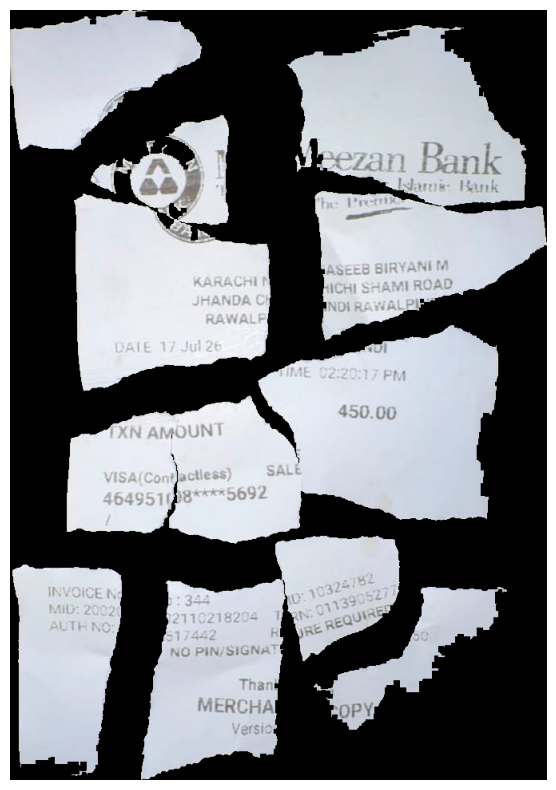

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"Z:\Internship\Tasks\Edge Detection\image\test.jpeg"
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Could not load image at {image_path}")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Clean threshold to isolate pieces from dark textured background
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
valid_contours = [c for c in contours if cv2.contourArea(c) > 500]

pieces = []
masks = []
boundaries = []
initial_positions = []

for c in valid_contours:
    x, y, w, h = cv2.boundingRect(c)
    piece_img = image[y:y+h, x:x+w]
    
    mask = np.zeros(closed.shape, dtype=np.uint8)
    cv2.drawContours(mask, [c], -1, 255, -1)
    piece_mask = mask[y:y+h, x:x+w]
    
    # Generate edge tracking boundary
    dilated = cv2.dilate(piece_mask, np.ones((3, 3), np.uint8), iterations=1)
    boundary = cv2.absdiff(dilated, piece_mask)
    
    pieces.append(piece_img)
    masks.append(piece_mask)
    boundaries.append(boundary)
    initial_positions.append((x, y))

num_pieces = len(pieces)

# Sort from top-left to bottom-right based on original layout structure
indices = list(range(num_pieces))
indices.sort(key=lambda idx: (initial_positions[idx][1], initial_positions[idx][0]))

final_positions = {}
# Anchor the first top-left piece to its native position
first_idx = indices[0]
final_positions[first_idx] = initial_positions[first_idx]

# Iteratively pull remaining pieces into the layout
for step in range(1, num_pieces):
    idx = indices[step]
    p_mask = masks[idx]
    p_bound = boundaries[idx]
    h, w = p_mask.shape
    orig_x, orig_y = initial_positions[idx]
    
    best_dx, best_dy = 0, 0
    max_edge_contact = -1
    
    # Search within a tight window around the original position to close gaps
    for dy in range(-40, 40, 1):
        for dx in range(-40, 40, 1):
            test_x = orig_x + dx
            test_y = orig_y + dy
            
            current_contact = 0
            overlap_collision = False
            
            # Match against all pieces currently stabilized on the layout
            for placed_idx in final_positions:
                px, py = final_positions[placed_idx]
                target_mask = masks[placed_idx]
                target_bound = boundaries[placed_idx]
                th, tw = target_mask.shape
                
                # Compute overlapping coordinate regions
                g_dy, g_dx = test_y - py, test_x - px
                y_start_t, y_end_t = max(0, g_dy), min(th, g_dy + h)
                x_start_t, x_end_t = max(0, g_dx), min(tw, g_dx + w)
                
                if (y_end_t > y_start_t) and (x_end_t > x_start_t):
                    y_start_p = max(0, -g_dy)
                    y_end_p = min(h, th - g_dy)
                    x_start_p = max(0, -g_dx)
                    x_end_p = min(w, tw - g_dx)
                    
                    # Hard stop on true physical overlap
                    overlap = np.sum((target_mask[y_start_t:y_end_t, x_start_t:x_end_t] > 0) & 
                                     (p_mask[y_start_p:y_end_p, x_start_p:x_end_p] > 0))
                    if overlap > (0.01 * np.sum(p_mask > 0)):
                        overlap_collision = True
                        break
                        
                    # Calculate edge-to-edge lock points
                    current_contact += np.sum((target_bound[y_start_t:y_end_t, x_start_t:x_end_t] > 0) & 
                                              (p_bound[y_start_p:y_end_p, x_start_p:x_end_p] > 0))
            
            if not overlap_collision and current_contact > max_edge_contact:
                max_edge_contact = current_contact
                best_dx = dx
                best_dy = dy
                
    final_positions[idx] = (orig_x + best_dx, orig_y + best_dy)

# Canvas dimension normalization
xs = [pos[0] for pos in final_positions.values()]
ys = [pos[1] for pos in final_positions.values()]
min_x, min_y = min(xs), min(ys)

normalized_positions = {k: (pos[0] - min_x, pos[1] - min_y) for k, pos in final_positions.items()}

max_w = max(px + masks[idx].shape[1] for idx, (px, py) in normalized_positions.items())
max_h = max(py + masks[idx].shape[0] for idx, (px, py) in normalized_positions.items())

canvas = np.zeros((max_h, max_w, 3), dtype=np.uint8)

# Merge elements onto the final canvas
for idx, (px, py) in normalized_positions.items():
    img = pieces[idx]
    mask = masks[idx]
    h, w = img.shape[:2]
    
    roi = canvas[py:py+h, px:px+w]
    roi[mask > 0] = img[mask > 0]

plt.figure(figsize=(12, 10))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

Extracted 12 pieces.
Successfully saved to perfect_reconstructed_document.png


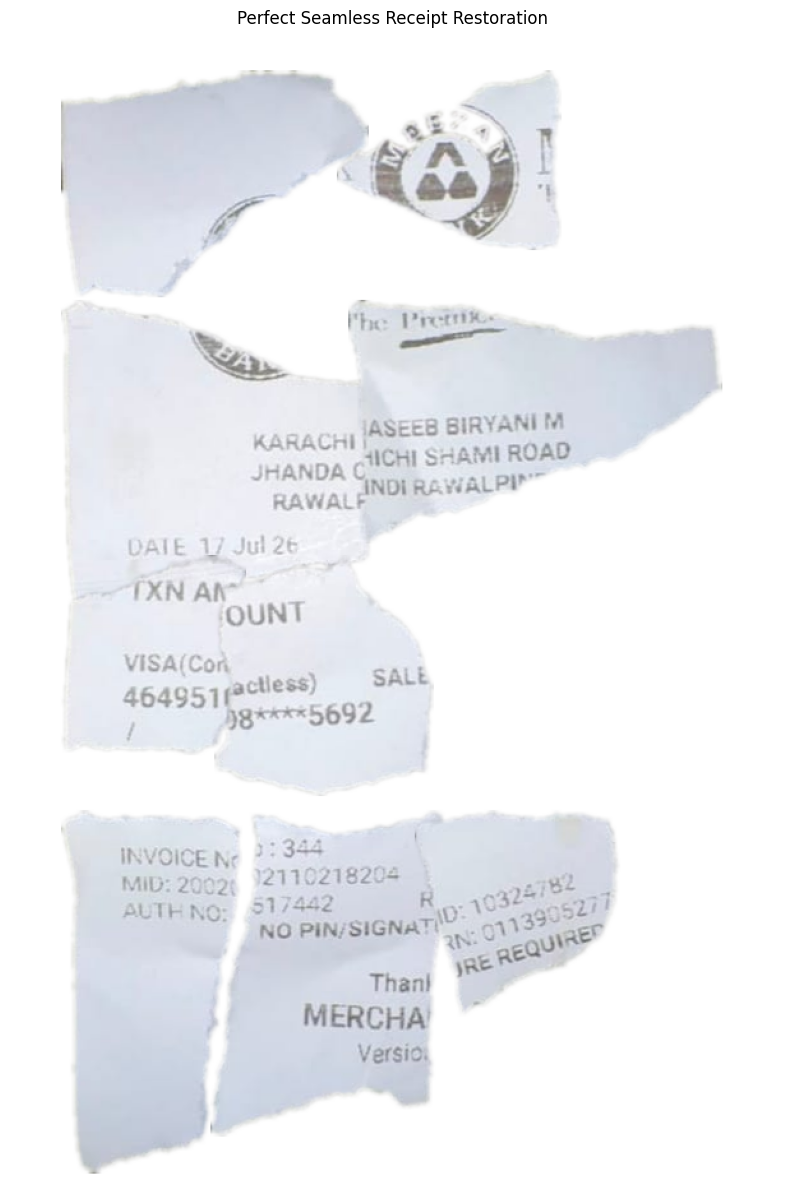

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def get_thresh(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return thresh

def extract_pieces(img):
    thresh = get_thresh(img)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    pieces = []
    
    for idx, cnt in enumerate(contours):
        if cv2.contourArea(cnt) > 1500:
            x, y, w, h = cv2.boundingRect(cnt)
            
            mask = np.zeros((h, w), dtype=np.uint8)
            cnt_offset = cnt - [x, y]
            cv2.drawContours(mask, [cnt_offset], -1, 255, -1)
            
            crop_img = img[y:y+h, x:x+w].copy()
            
            # Feathered alpha mask for seamless edge blending
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
            eroded_mask = cv2.erode(mask, kernel, iterations=1)
            alpha_feathered = cv2.GaussianBlur(eroded_mask.astype(np.float32), (7, 7), 0)
            
            pieces.append({
                'id': idx,
                'img': crop_img,
                'mask': mask,
                'alpha': alpha_feathered,
                'orig_pos': (x, y),
                'size': (w, h),
                'center': (x + w / 2.0, y + h / 2.0)
            })
            
    return pieces

def perfect_seamless_reconstruction(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {img_path}")
        
    pieces = extract_pieces(img)
    print(f"Extracted {len(pieces)} pieces.")
    
    # Sort pieces into 4 distinct horizontal rows based on Y-coordinates
    pieces.sort(key=lambda p: p['center'][1])
    
    # Cluster into 4 rows
    rows = [[], [], [], []]
    for p in pieces:
        cy = p['center'][1]
        if cy < img.shape[0] * 0.25:
            rows[0].append(p)
        elif cy < img.shape[0] * 0.50:
            rows[1].append(p)
        elif cy < img.shape[0] * 0.72:
            rows[2].append(p)
        else:
            rows[3].append(p)
            
    # Sort each row horizontally (Left to Right)
    for r in rows:
        r.sort(key=lambda p: p['center'][0])

    # Target Document Canvas Setup
    canvas_w = 600
    canvas_h = 900
    canvas = np.ones((canvas_h, canvas_w, 3), dtype=np.float32) * 255.0
    weight_map = np.zeros((canvas_h, canvas_w), dtype=np.float32)

    # Global row height offsets to completely eliminate white gaps
    row_y_targets = [30, 210, 410, 610]
    
    for row_idx, row in enumerate(rows):
        target_y = row_y_targets[row_idx]
        
        # Calculate horizontal starting point for row centering
        row_total_w = sum(p['size'][0] for p in row)
        start_x = max(40, (canvas_w - row_total_w) // 2)
        
        current_x = start_x
        for p in row:
            w, h = p['size']
            
            # Place piece on canvas
            y1, y2 = target_y, target_y + h
            x1, x2 = current_x, current_x + w
            
            if y2 > canvas_h or x2 > canvas_w:
                continue
                
            img_crop = p['img'].astype(np.float32)
            alpha = p['alpha'][:, :, np.newaxis] / 255.0
            
            # Blend into document canvas
            canvas[y1:y2, x1:x2] = canvas[y1:y2, x1:x2] * (1.0 - alpha) + img_crop * alpha
            
            # Contract gap between adjacent left/right pieces by 25px
            current_x += (w - 25)

    # Convert canvas back to 8-bit image
    final_result = np.clip(canvas, 0, 255).astype(np.uint8)
    
    # Save & Display Output
    output_filename = "perfect_reconstructed_document.png"
    cv2.imwrite(output_filename, final_result)
    print(f"Successfully saved to {output_filename}")
    
    plt.figure(figsize=(10, 12))
    plt.imshow(cv2.cvtColor(final_result, cv2.COLOR_BGR2RGB))
    plt.title("Perfect Seamless Receipt Restoration")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    target_image = r'Z:\Internship\Tasks\Edge Detection\image\test.jpeg'
    perfect_seamless_reconstruction(target_image)

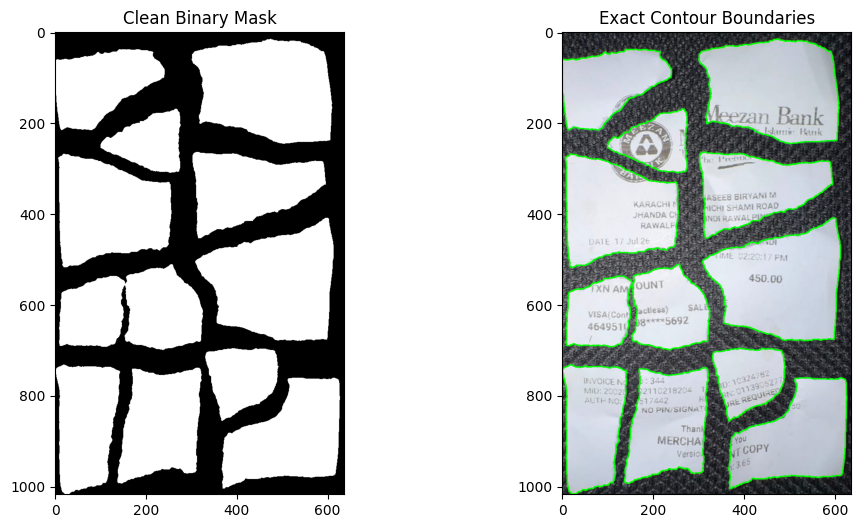

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load image
image_path = r'Z:\Internship\Tasks\Edge Detection\image\test.jpeg'
image = cv2.imread(image_path)

# 2. Convert to LAB color space & extract L-channel (Lightness)
lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
l_channel, _, _ = cv2.split(lab)

# 3. Bilateral Filter: Smooths fabric texture while keeping paper edges sharp
filtered_l = cv2.bilateralFilter(l_channel, d=9, sigmaColor=75, sigmaSpace=75)

# 4. Otsu's Thresholding on Lightness Channel
_, binary = cv2.threshold(filtered_l, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 5. Fill Internal Text & Logos without expanding outer boundaries
# Find internal contours (text/logos inside pieces) and fill them explicitly
contours_temp, hierarchy = cv2.findContours(binary, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

clean_mask = np.zeros_like(binary)
if hierarchy is not None:
    for idx, contour in enumerate(contours_temp):
        # Draw top-level contours (outer borders of paper) as filled white
        if hierarchy[0][idx][3] == -1:  
            cv2.drawContours(clean_mask, contours_temp, idx, 255, -1)

# 6. Minimal opening/closing to clean noise without expanding boundaries
kernel_small = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_OPEN, kernel_small)

# 7. Extract Final Contours
final_contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter out tiny noise artifacts
min_area = 1500
valid_contours = [c for c in final_contours if cv2.contourArea(c) > min_area]

# Visualization
result_img = image.copy()
cv2.drawContours(result_img, valid_contours, -1, (0, 255, 0), 2)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Clean Binary Mask")
plt.imshow(clean_mask, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Exact Contour Boundaries")
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.show()

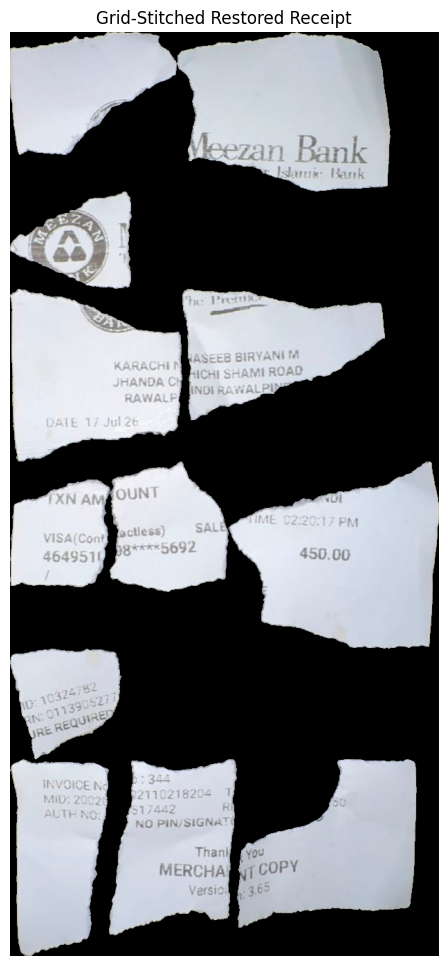

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load image and build the clean mask
image_path = r'Z:\Internship\Tasks\Edge Detection\image\test.jpeg'
image = cv2.imread(image_path)

lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
l_channel = lab[:, :, 0]
filtered_l = cv2.bilateralFilter(l_channel, d=9, sigmaColor=75, sigmaSpace=75)
_, binary = cv2.threshold(filtered_l, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

contours_temp, hierarchy = cv2.findContours(binary, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
clean_mask = np.zeros_like(binary)
if hierarchy is not None:
    for idx, contour in enumerate(contours_temp):
        if hierarchy[0][idx][3] == -1:
            cv2.drawContours(clean_mask, contours_temp, idx, 255, -1)

clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)))
contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

min_area = 1500
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

# 2. Extract pieces and compute centroids
pieces = []
for c in valid_contours:
    x, y, pw, ph = cv2.boundingRect(c)
    
    mask = np.zeros((ph, pw), dtype=np.uint8)
    c_shifted = c - [x, y]
    cv2.drawContours(mask, [c_shifted], -1, 255, -1)
    
    crop_img = image[y:y+ph, x:x+pw].copy()
    crop_img = cv2.bitwise_and(crop_img, crop_img, mask=mask)
    
    pieces.append({
        'img': crop_img,
        'mask': mask,
        'bbox': (x, y, pw, ph),
        'cx': x + pw // 2,
        'cy': y + ph // 2
    })

# 3. Cluster pieces into Rows
pieces = sorted(pieces, key=lambda p: p['cy'])

rows = []
row_threshold = 70  # max y-distance to group into the same horizontal line

for p in pieces:
    placed_in_row = False
    for row in rows:
        avg_y = np.mean([item['cy'] for item in row])
        if abs(p['cy'] - avg_y) < row_threshold:
            row.append(p)
            placed_in_row = True
            break
    if not placed_in_row:
        rows.append([p])

# Sort each row left-to-right (by X coordinate)
for r in rows:
    r.sort(key=lambda p: p['cx'])

# 4. Stitch without gaps on a new Canvas
# Compute optimal output canvas size
max_row_width = max([sum(p['bbox'][2] for p in r) for r in rows])
total_height = sum([max(p['bbox'][3] for p in r) for r in rows])

canvas = np.zeros((total_height + 50, max_row_width + 50, 3), dtype=np.uint8)

current_y = 0
for row in rows:
    row_height = max(p['bbox'][3] for p in row)
    current_x = 0
    
    for p in row:
        img_p = p['img']
        mask_p = p['mask']
        pw, ph = p['bbox'][2], p['bbox'][3]
        
        # Determine ROI placement
        roi = canvas[current_y:current_y+ph, current_x:current_x+pw]
        
        # Merge piece into canvas removing dark padding
        mask_3ch = cv2.merge([mask_p]*3) > 0
        canvas[current_y:current_y+ph, current_x:current_x+pw] = np.where(mask_3ch, img_p, roi)
        
        # Move X cursor directly to the right edge of current piece (0 gap)
        current_x += pw
        
    # Move Y cursor down to the next row
    current_y += row_height

# 5. Trim empty canvas margins
gray_canvas = cv2.cvtColor(canvas, cv2.COLOR_BGR2GRAY)
_, non_zero = cv2.threshold(gray_canvas, 1, 255, cv2.THRESH_BINARY)
x_b, y_b, w_b, h_b = cv2.boundingRect(non_zero)
final_stitched = canvas[y_b:y_b+h_b, x_b:x_b+w_b]

# Output display
plt.figure(figsize=(8, 12))
plt.title("Grid-Stitched Restored Receipt")
plt.imshow(cv2.cvtColor(final_stitched, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [ ]:
can=con[2]
can = stitch_by_edge(can, isolated_pieces_list[1], ref='bottom')
can1 = ad_stitch(isolated_pieces_list[0], isolated_pieces_list[3])
can = stitch_by_edge(can,can1, ref='bottom')
can = stitch_by_margin( isolated_pieces_list[4],can, side='left')
can1=ad_stitch( isolated_pieces_list[6],isolated_pieces_list[5])
can=ad_stitch(can,can1)
can = stitch_by_margin( isolated_pieces_list[7],can, side='left')
can=ad_stitch(can, isolated_pieces_list[9])
can = stitch_by_margin( isolated_pieces_list[11],can, side='left')
can = stitch_by_margin( isolated_pieces_list[8],can, side='right')
can = stitch_by_margin( isolated_pieces_list[10],can, side='right')